In [44]:

import librosa
print(librosa.__version__)
import IPython.display as ipd
import matplotlib.pyplot as plt

0.11.0


In [35]:
import pandas as pd
import numpy as np

In [9]:
ipd.Audio(path)

In [4]:
path = librosa.ex('choice')
y, sr = librosa.load(path)
print(f"Successfully loaded example. Sampling rate: {sr}")
print(len(y), sr)

Successfully loaded example. Sampling rate: 22050
551823 22050


In [11]:
y

array([ 1.02893655e-05,  1.97995837e-06,  2.52699715e-06, ...,
        4.25853750e-06, -7.86152486e-06, -1.86528869e-05],
      shape=(551823,), dtype=float32)

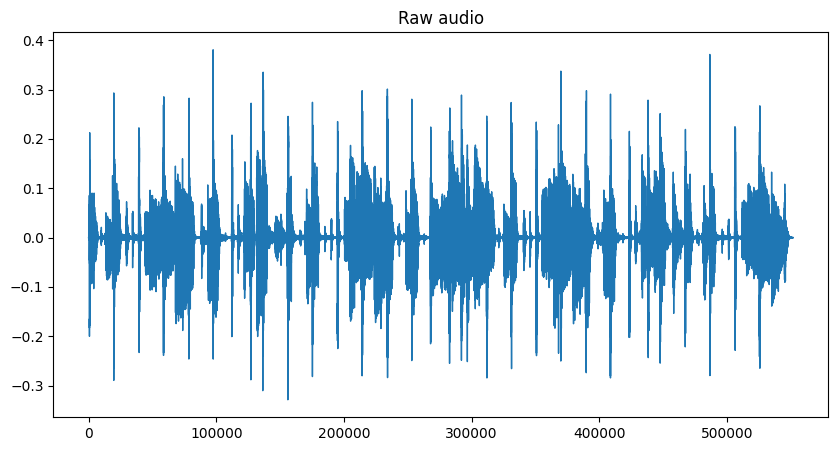

In [18]:
pd.Series(y).plot(figsize=(10,5),
                 lw=1,
                 title='Raw audio')
plt.show()

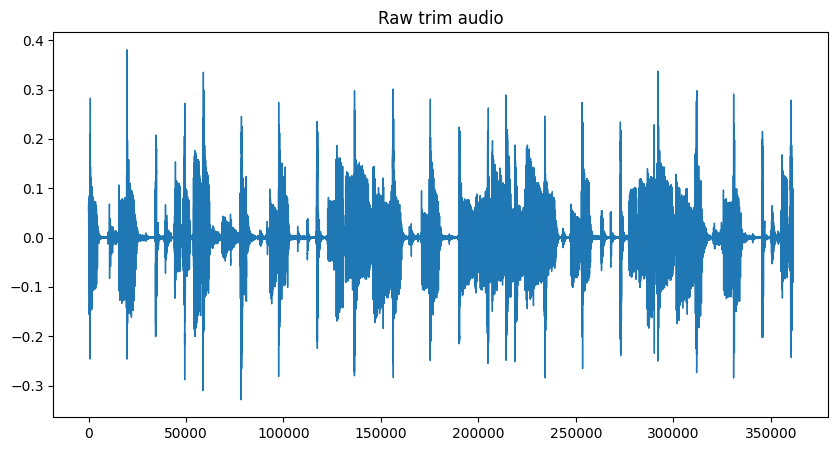

In [26]:
y_trim,_= librosa.effects.trim(y,top_db=2)
pd.Series(y_trim).plot(figsize=(10,5),
                 lw=1,
                 title='Raw trim audio',)
plt.show()

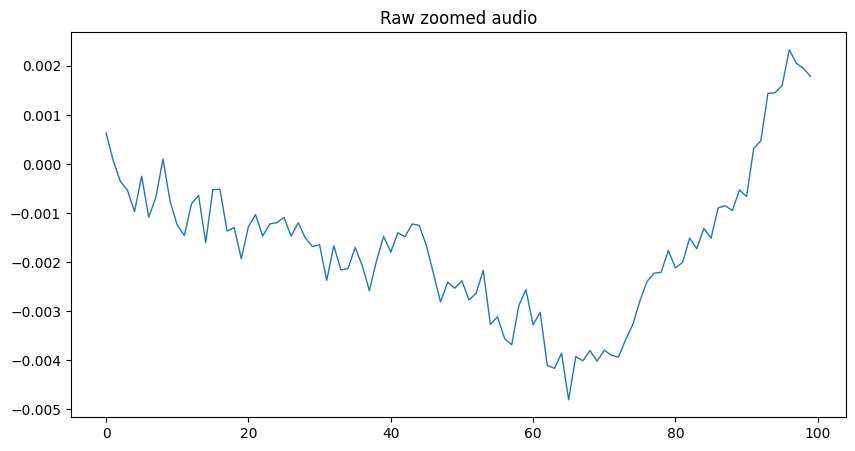

In [32]:
pd.Series(y[240000:240100]).plot(figsize=(10,5),
                 lw=1,
                 title='Raw zoomed audio')
plt.show()

In [38]:
D=librosa.stft(y)
s_db=librosa.amplitude_to_db(np.abs(D),ref=np.max)

In [39]:
s_db.shape

(1025, 1078)

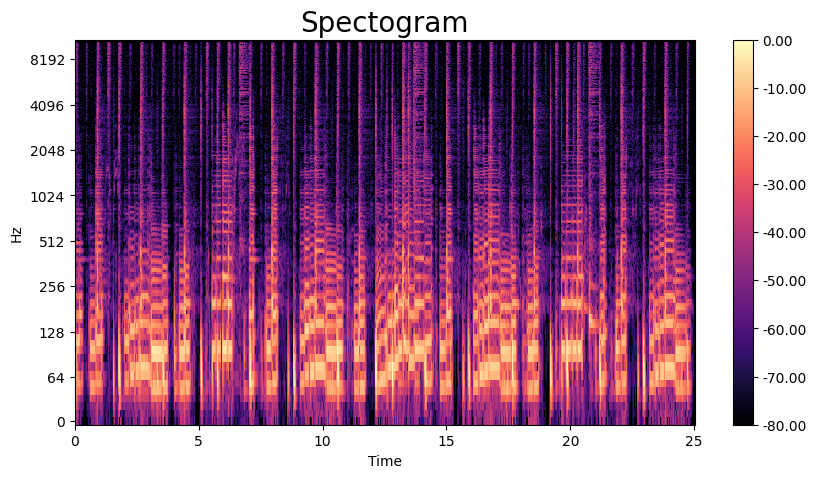

In [49]:
fig,ax=plt.subplots(figsize=(10,5))
img=librosa.display.specshow(s_db,
                             x_axis='time',
                             y_axis='log',
                             ax=ax)
ax.set_title('Spectogram',fontsize=20)
fig.colorbar(img,ax=ax,format=f'%0.2f')

In [66]:
S= librosa.feature.melspectrogram(y=y,sr=sr,n_mels=256)
s_db_mel= librosa.power_to_db(S, ref=np.max)

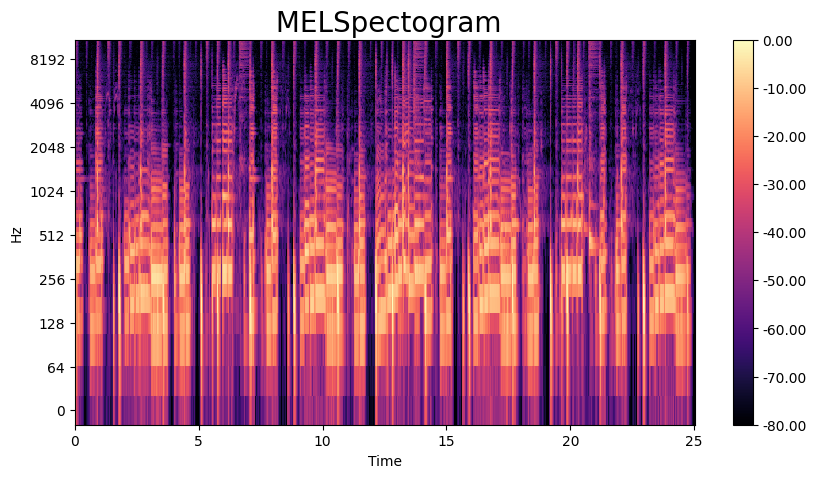

In [67]:
fig,ax=plt.subplots(figsize=(10,5))
img=librosa.display.specshow(s_db_mel,
                             x_axis='time',
                             y_axis='log',
                             ax=ax)
ax.set_title(' MELSpectogram',fontsize=20)
fig.colorbar(img,ax=ax,format=f'%0.2f')

In [62]:
import tensorflow as tf

In [87]:
num_mel=256
num_of_bird_species=0
hop_length=512
width= (5*32000)/hop_length #its 312.5  but we will use 312

In [82]:

eff_B0=tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(num_mel,312,3),
    pooling='avg',
)
model= tf.keras.Sequential([
    eff_B0,
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(num_of_bird_species,activation='softmax')
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [83]:
def process_audio_efficientB0(file_path,labels):
    y, sr = librosa.load(file_path.numpy(), sr=32000, duration=5.0) #used to load at 5 seconds duration at 32KHz
    target_length = 5 * 32000  # since audio looks at frames, the number of samples is duration*frequency
    if len(y) < target_length: #all data is not the duration, so we need to pad it
        y=np.pad(y,(0,target_length - len(y)))
    spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmin=20, fmax=16000) 
    #we use between min 20Hz to get rid of noise due to earth
    #and frequency max is apparently due to Nyquist-Shannon Theorem fmax is half of sampled rate of 32Khz
    #one thing to note is that melspectrogram uses output in terms of power instead of amplitude, so using amplitude_to_db actually 
    # reduces db by a factor of 2, so we use power_to_db instead
    spec_db = librosa.power_to_db(spec, ref=np.max)
    spec_db= (spec_db-spec_db.min())/(spec_db.max()-spec_db.min()+1e-6) #normalization step for audio stuff, 1e-6 is there to prevent 
    #zero division
    spec_db=spec_db[...,np.newaxis] #makes from 2D to 3D
    spec_db = np.repeat(spec_db, 3, axis=-1) #because efficientnet requires rgb channel
    return spec_db.astype(np.float32),label

In [84]:
def prepare_dataset(file_path,labels,batch_size=16):
    ds= tf.data.Dataset.from_tensor_slices((file_path,labels)) #makes a dataset of strings and labels
    ds = ds.shuffle(buffer_size=len(file_paths)) #buffer_size is how far away we are going to shuffle
    ds = ds.map(
        lambda x, y: tf.py_function(process_audio, [x, y], [tf.float32, tf.int32]),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    """
        So there is quite abit to explain here,
        1)first is the mapping function, its just a transformation tool.
        2)since tensorflow and librosa are not exactly compatible(due to the nature of how they run), we use a external function called
        py_function, it acts like the middle man allowing process_audio to run in python.
        3)processes multiple audio files at the same time, essentially a speed boost, tensorflow looks at the number of cores the device has
    """
    def set_shape(img,label):
        img.set_shape((num_mel,None,3)) #when we move to python in py_function, it tends to forget the shape
        label.set_shape([]) #[] indicates its a scalar
        return img,label
    ds = ds.map(set_shapes)
    ds = ds.batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
    # data goes from (128, 312, 3) to (batch_size, 128, 312, 3), this is alot faster as we are processing 16 at a time
    #prefetch is another function we use for faster performance, prevents idling of cpu/gpu
    return ds

    
    

In [85]:
#model setup, we use SparseCategoricalCrossentropy in the event the the labels are integers like 0,1,2,3,...
#and apparently Adam is used frequently
#we are using metric as accuracy, but we should care about F1 score and validation loss(means new data it has never seen before)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
"""
Callbacks/safety nets(mostly to save time):
EarlyStopping: Stops the training if the validation loss doesn't improve for 5-10 epochs.

ModelCheckpoint: Automatically saves your "best" model weights to a file so you don't lose progress if your laptop sleeps or crashes.

ReduceLROnPlateau: If the model's progress slows down, this "shrinks" the learning rate to help the model find the very bottom of the 
loss curve.
"""
EPOCHS = 50 # Start with 50; EarlyStopping will likely cut it short

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("best_bird_model.keras", save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3)
    ]
)


NameError: name 'train_ds' is not defined

In [81]:
#making code to mke validation data

NameError: name 'spec_db' is not defined